We use five ETFs representing different market segments:

- **SPY** — large US companies from the S&P 500
- **QQQ** — large growth companies, heavily weighted toward technology
- **IWM** — smaller US companies from the Russell 2000
- **TLT** — long-term US government bonds
- **GLD** — gold

The goal is to create a small and diversified investment universe.

Later, the model will learn how to distribute probability across these assets based on current market conditions.

# Data

In [1]:
!pip -q install -q yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import torch
import torch.nn as nn
import torch.nn.functional as F

tickers = [
    "SPY",  # USA
    "QQQ",  # tech
    "IWM",  # small caps
    "TLT",  # bonds
    "GLD",  # gold
]

prices = yf.download(
    tickers,
    start="2015-01-01",
    interval="1d",
    auto_adjust=True,
    progress=False,
)["Close"]

prices = prices.dropna()

print(prices.shape)
prices.tail()

(2911, 5)


Ticker,GLD,IWM,QQQ,SPY,TLT
Date,,,,,
2026-07-27,374.630005,292.910004,682.119995,739.090027,83.750000
2026-07-28,369.369995,293.369995,675.489990,740.859985,84.239998
2026-07-29,371.079987,288.570007,661.729980,729.460022,82.849998
2026-07-30,377.160004,292.589996,683.549988,741.690002,82.800003
2026-07-31,371.540009,291.200012,687.989990,747.030029,82.250000


In [10]:
print("Minimum date:", prices.index.min())
print("Maximum date:", prices.index.max())

Minimum date: 2015-01-02 00:00:00
Maximum date: 2026-07-31 00:00:00


# Daily Return

In [11]:
returns = prices.pct_change().dropna()

print("Returns shape:", returns.shape)
returns.tail()

Returns shape: (2910, 5)


Ticker,GLD,IWM,QQQ,SPY,TLT
Date,,,,,
2026-07-27,0.007341,0.005976,-0.003084,0.000217,0.006006
2026-07-28,-0.014041,0.001570,-0.009720,0.002395,0.005851
2026-07-29,0.004629,-0.016362,-0.020370,-0.015387,-0.016500
2026-07-30,0.016385,0.013931,0.032974,0.016766,-0.000603
2026-07-31,-0.014901,-0.004751,0.006496,0.007200,-0.006643


# Build Training Sequences and Target Distributions

For each trading day, the model receives the previous 20 days of returns for all five assets, while the target is a probability distribution based on their returns over the following 5 trading days.

In [14]:
lookback = 20
horizon = 5
temperature = 0.02

X = []
targets = []
dates = []

for t in range(lookback, len(prices) - horizon):

    past_prices = prices.iloc[t - lookback:t + 1]

    past_returns = (
        past_prices
        .pct_change()
        .dropna()
        .to_numpy()
    )

    future_returns = (
        prices.iloc[t + horizon].to_numpy()
        / prices.iloc[t].to_numpy()
        - 1
    )

    target_probs = torch.softmax(
        torch.tensor(
            future_returns / temperature,
            dtype=torch.float32,
        ),
        dim=0,
    )

    X.append(past_returns)
    targets.append(target_probs.numpy())
    dates.append(prices.index[t])

X = torch.tensor(
    np.array(X),
    dtype=torch.float32,
)

targets = torch.tensor(
    np.array(targets),
    dtype=torch.float32,
)

print("Input shape:", X.shape)
print("Target shape:", targets.shape)

Input shape: torch.Size([2886, 20, 5])
Target shape: torch.Size([2886, 5])


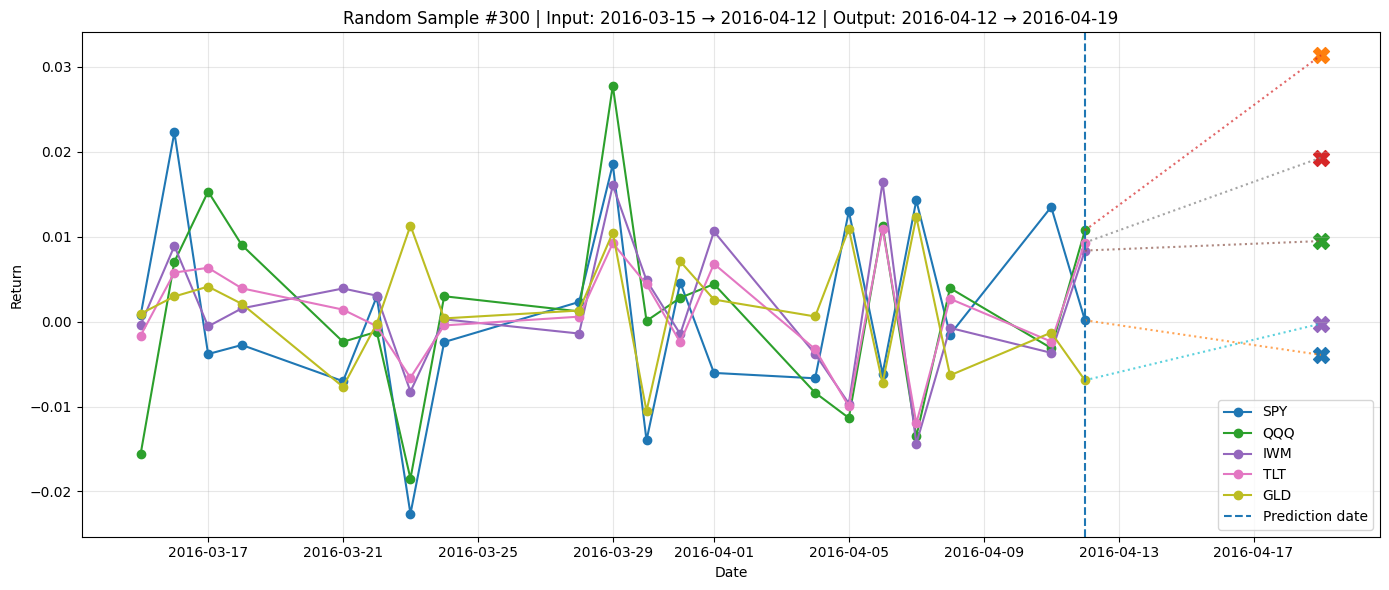

In [31]:
random_idx = np.random.randint(len(X))

random_input = X[random_idx].numpy()
random_date = dates[random_idx]

t = prices.index.get_loc(random_date)

input_dates = prices.index[t - lookback + 1:t + 1]
target_date = prices.index[t + horizon]

future_returns = (
    prices.iloc[t + horizon].to_numpy()
    / prices.iloc[t].to_numpy()
    - 1
)

plt.figure(figsize=(14, 6))

for i, ticker in enumerate(tickers):
    plt.plot(
        input_dates,
        random_input[:, i],
        marker="o",
        label=ticker,
    )

    plt.plot(
        [random_date, target_date],
        [random_input[-1, i], future_returns[i]],
        linestyle="dotted",
        alpha=0.7,
    )

    plt.scatter(
        target_date,
        future_returns[i],
        marker="X",
        s=130,
    )

plt.axvline(
    random_date,
    linestyle="--",
    label="Prediction date",
)

plt.title(
    f"Random Sample #{random_idx} | "
    f"Input: {input_dates[0].date()} → {input_dates[-1].date()} | "
    f"Output: {random_date.date()} → {target_date.date()}"
)
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Split Data Chronologically

We split the samples by date so the model is trained only on the past and evaluated on later unseen market data.

In [32]:
train_ratio = 0.8
split_idx = int(len(X) * train_ratio)

X_train = X[:split_idx]
y_train = targets[:split_idx]

X_test = X[split_idx:]
y_test = targets[split_idx:]

train_dates = dates[:split_idx]
test_dates = dates[split_idx:]

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

print("Train range:", train_dates[0].date(), "→", train_dates[-1].date())
print("Test range:", test_dates[0].date(), "→", test_dates[-1].date())

Train: torch.Size([2308, 20, 5]) torch.Size([2308, 5])
Test: torch.Size([578, 20, 5]) torch.Size([578, 5])
Train range: 2015-02-02 → 2024-04-03
Test range: 2024-04-04 → 2026-07-24


# Define the Transformer Model

The transformer receives 20 daily return vectors, compresses the sequence into one representation, and outputs a probability distribution across the five assets.

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_assets = len(tickers)
embed_dim = 32
n_heads = 4
n_blocks = 2

assert embed_dim % n_heads == 0

In [34]:
class MultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()

        self.num_heads = n_heads
        self.head_dim = embed_dim // n_heads

        self.QKV = nn.Linear(
            embed_dim,
            3 * embed_dim,
            bias=True,
        )

        self.WO = nn.Linear(
            embed_dim,
            embed_dim,
            bias=True,
        )

    def forward(self, x):
        B, T, E = x.shape

        qkv = self.QKV(x)
        q, k, v = torch.split(qkv, E, dim=2)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        out = F.scaled_dot_product_attention(
            q,
            k,
            v,
            is_causal=True,
        )

        out = out.transpose(1, 2).contiguous().view(B, T, E)
        out = self.WO(out)

        return out

In [35]:
class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()

        self.layernorm_1 = nn.LayerNorm(embed_dim, eps=1e-5)
        self.attn = MultiHeadAttention()

        self.layernorm_2 = nn.LayerNorm(embed_dim, eps=1e-5)

        self.mlp_1 = nn.Linear(embed_dim, 4 * embed_dim)
        self.gelu = nn.GELU()
        self.mlp_2 = nn.Linear(4 * embed_dim, embed_dim)

    def forward(self, x):

        x = x + self.attn(
            self.layernorm_1(x)
        )

        x = x + self.mlp_2(
            self.gelu(
                self.mlp_1(
                    self.layernorm_2(x)
                )
            )
        )

        return x

In [36]:
class FinancialTransformer(nn.Module):
    def __init__(self):
        super().__init__()

        # Project 5 asset returns into embedding space
        self.input_projection = nn.Linear(
            num_assets,
            embed_dim,
        )

        # Learnable position embeddings for 20 timesteps
        self.position_embedding = nn.Embedding(
            lookback,
            embed_dim,
        )

        # Transformer blocks
        self.transformer_blocks = nn.Sequential(
            *[TransformerBlock() for _ in range(n_blocks)]
        )

        # Final normalization
        self.layernorm_final = nn.LayerNorm(
            embed_dim,
            eps=1e-5,
        )

        # Output one score for each asset
        self.final_head = nn.Linear(
            embed_dim,
            num_assets,
        )

    def forward(self, x):
        B, T, _ = x.shape

        input_emb = self.input_projection(x)

        positions = torch.arange(
            T,
            device=x.device,
        )

        position_emb = self.position_embedding(positions)

        x = input_emb + position_emb

        x = self.transformer_blocks(x)
        x = self.layernorm_final(x)

        # Use the final timestep representation
        logits = self.final_head(x[:, -1, :])

        return F.log_softmax(logits, dim=-1)

In [37]:
model = FinancialTransformer().to(device)

X_train = X_train.to(device)
y_train = y_train.to(device)

X_test = X_test.to(device)
y_test = y_test.to(device)

loss_function = nn.KLDivLoss(reduction="batchmean")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-2,
)

print(model)

FinancialTransformer(
  (input_projection): Linear(in_features=5, out_features=32, bias=True)
  (position_embedding): Embedding(20, 32)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (layernorm_1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (QKV): Linear(in_features=32, out_features=96, bias=True)
        (WO): Linear(in_features=32, out_features=32, bias=True)
      )
      (layernorm_2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (mlp_1): Linear(in_features=32, out_features=128, bias=True)
      (gelu): GELU(approximate='none')
      (mlp_2): Linear(in_features=128, out_features=32, bias=True)
    )
    (1): TransformerBlock(
      (layernorm_1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (QKV): Linear(in_features=32, out_features=96, bias=True)
        (WO): Linear(in_features=32, out_features=32, bias=True)
      )
      (layernorm_2): LayerN

# DataLoaders

In [38]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

# Train

In [39]:
num_epochs = 100

train_losses = []
test_losses = []

for epoch in range(num_epochs):

    # Training
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        log_probs = model(X_batch)

        loss = loss_function(
            log_probs,
            y_batch,
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    # Evaluation
    model.eval()
    test_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            log_probs = model(X_batch)

            loss = loss_function(
                log_probs,
                y_batch,
            )

            test_loss += loss.item() * X_batch.size(0)

    test_loss /= len(test_dataset)
    test_losses.append(test_loss)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Train KL: {train_loss:.4f} | "
            f"Test KL: {test_loss:.4f}"
        )

Epoch   0 | Train KL: 0.2783 | Test KL: 0.2861
Epoch  10 | Train KL: 0.2569 | Test KL: 0.2834
Epoch  20 | Train KL: 0.2563 | Test KL: 0.2835
Epoch  30 | Train KL: 0.2559 | Test KL: 0.2844
Epoch  40 | Train KL: 0.2556 | Test KL: 0.2850
Epoch  50 | Train KL: 0.2553 | Test KL: 0.2856
Epoch  60 | Train KL: 0.2551 | Test KL: 0.2858
Epoch  70 | Train KL: 0.2549 | Test KL: 0.2861
Epoch  80 | Train KL: 0.2547 | Test KL: 0.2864
Epoch  90 | Train KL: 0.2545 | Test KL: 0.2865


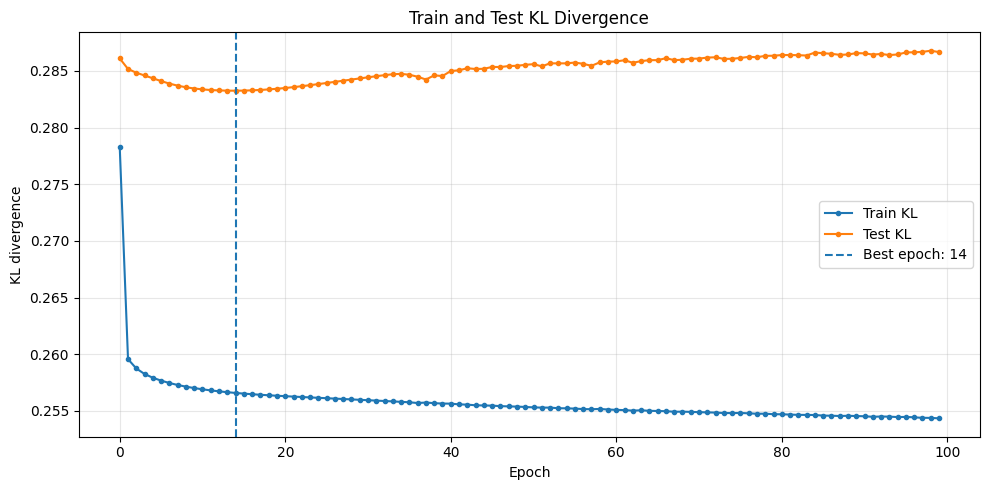

Best epoch: 14
Best test KL: 0.2832504893978574


In [40]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, "-o", markersize=3, label="Train KL")
plt.plot(test_losses, "-o", markersize=3, label="Test KL")

best_epoch = int(np.argmin(test_losses))
best_test_loss = test_losses[best_epoch]

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)

plt.title("Train and Test KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("KL divergence")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Best epoch:", best_epoch)
print("Best test KL:", best_test_loss)

# Conclusion

The model learned the training data but failed to generalize to the test set. This suggests that the previous 20 raw daily returns do not contain a sufficiently stable signal for predicting the future distribution of winning assets in this setup.